# 📊 E-Commerce Sales Analysis



---

## 📌 Problem Statement
This project analyzes e-commerce transaction data to identify key patterns in sales, customer behavior, and product performance.

The objective is to generate **data-driven insights** that can help businesses improve revenue, optimize inventory, and enhance customer retention strategies.

In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [329]:
df=pd.read_csv("/content/Sales Transaction v.4a.csv")
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [330]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


### 🔍 Insight:
The dataset contains a mix of numerical and categorical columns.

👉 Importance:
Understanding data types helps in selecting appropriate analysis and visualization techniques.

In [331]:
df.columns

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country'],
      dtype='object')

In [332]:
df.isnull().sum()
df.dropna(inplace=True)
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [333]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [334]:
# Date : YYYY-MM-DD
df["Date"]=pd.to_datetime(df["Date"])
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,2018-12-01,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,2018-12-01,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,2018-12-01,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,2018-12-01,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


In [335]:
df=df[df["Quantity"]>0]
df=df[df["Price"]>0]
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536320,536585,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,2,17460.0,United Kingdom
536321,536590,2018-12-01,22776,Sweetheart 3 Tier Cake Stand,20.45,1,13065.0,United Kingdom
536322,536590,2018-12-01,22622,Box Of Vintage Alphabet Blocks,20.45,2,13065.0,United Kingdom
536323,536591,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,1,14606.0,United Kingdom


In [336]:
df['Country'].value_counts()

,count
Country,
United Kingdom,472716
France,10377
Germany,10221
EIRE,7783
Belgium,2507
Spain,2382
Netherlands,2326
Switzerland,2297
Portugal,1830


### 🔍 Insight:
This shows how many transactions are coming from each country.

👉 Observation:
A few countries contribute a significantly higher number of transactions compared to others.

👉 Business Meaning:
This indicates that the business is more active and popular in certain regions.

👉 Key Insight:
The dataset is **geographically imbalanced**, meaning most of the sales are concentrated in limited countries.

👉 Business Impact:
- High-performing countries → Major revenue drivers  
- Low-performing countries → Growth opportunities  



In [337]:
df["Total Amount"]=df["Price"]*df["Quantity"]
df["Month"]=df["Date"].dt.month
df["Day"]=df["Date"].dt.day
df["Year"]=df["Date"].dt.year
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Total Amount,Month,Day,Year
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,12,9,2019
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,12,9,2019
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,12,9,2019
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80,12,9,2019
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64,12,9,2019
...,...,...,...,...,...,...,...,...,...,...,...,...
536320,536585,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,2,17460.0,United Kingdom,40.90,12,1,2018
536321,536590,2018-12-01,22776,Sweetheart 3 Tier Cake Stand,20.45,1,13065.0,United Kingdom,20.45,12,1,2018
536322,536590,2018-12-01,22622,Box Of Vintage Alphabet Blocks,20.45,2,13065.0,United Kingdom,40.90,12,1,2018
536323,536591,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,1,14606.0,United Kingdom,20.45,12,1,2018


### 🔍 Insight:
A new column "Total_Amount" was created to calculate total revenue per transaction.

👉 Importance:
This is a key metric for analyzing sales performance and revenue trends.
### 🔍 Insight:
New time-based features (Month, Year) were extracted from the date column.

👉 Importance:
These features help in identifying seasonal trends and patterns in sales.

In [338]:
# Lowest Revenue Product
df.groupby("ProductName")["Total Amount"].sum().sort_values().head(1)

,Total Amount
ProductName,
Set 10 Cards Snowy Robin 17099,6.19


In [339]:
class ECommerceAnalysis:
  def __init__(self,df):
    self.df=df
  def top_products(self):
    return self.df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head()
  def least_products(self):
    return self.df.groupby("ProductName")["Quantity"].sum().sort_values().head()
  def top_customers(self):
    return self.df.groupby("CustomerNo")["Quantity"].sum().sort_values(ascending=False).head()
  def Country_sales(self):
    return self.df.groupby("Country")["Total Amount"].sum().sort_values(ascending=False).head()
  def monthly_sales(self):
    return self.df.groupby("Month")["Total Amount"].sum().sort_values(ascending=False)

In [340]:
analysis=ECommerceAnalysis(df)
print(f"Top Products :\n{analysis.top_products()}")
print(f"Least Products :\n{analysis.least_products()}")
print(f"Top Customers :\n{analysis.top_customers()}")
print(f"Country Sales :\n{analysis.Country_sales()}")
print(f"Monthly Sales :\n{analysis.monthly_sales()}")

Top Products :
ProductName
Paper Craft Little Birdie            80995
Medium Ceramic Top Storage Jar       78033
Popcorn Holder                       56902
World War 2 Gliders Asstd Designs    54951
Jumbo Bag Red Retrospot              48375
Name: Quantity, dtype: int64
Least Products :
ProductName
Wire Flower T-Light Holder         1
Dolphin Windmill                   1
Gardeners Kneeling Pad             1
Funky Monkey Mug                   1
Set Of Three Vintage Gift Wraps    1
Name: Quantity, dtype: int64
Top Customers :
CustomerNo
14646.0    197420
16446.0     80997
14911.0     80354
12415.0     77669
12346.0     74215
Name: Quantity, dtype: int64
Country Sales :
Country
United Kingdom    52346795.60
Netherlands        2151553.59
EIRE               1711819.39
Germany            1369839.62
France             1329903.39
Name: Total Amount, dtype: float64
Monthly Sales :
Month
11    7828489.53
10    7212279.85
12    6909717.91
9     6613772.79
8     4749801.23
7     4571494.88
5     4

### 🔍 Insight:
The analysis is structured using a class-based approach, where all operations are organized into reusable methods.

👉 This follows the concept of **feature abstraction**, where complex analysis steps are simplified into separate functions like top products, customers, and sales trends.

👉 Importance:
This makes the code more organized, reusable, and easy to maintain.

👉 Business Meaning:
Different business insights (products, customers, countries, sales trends) can be generated efficiently from a single structured system.

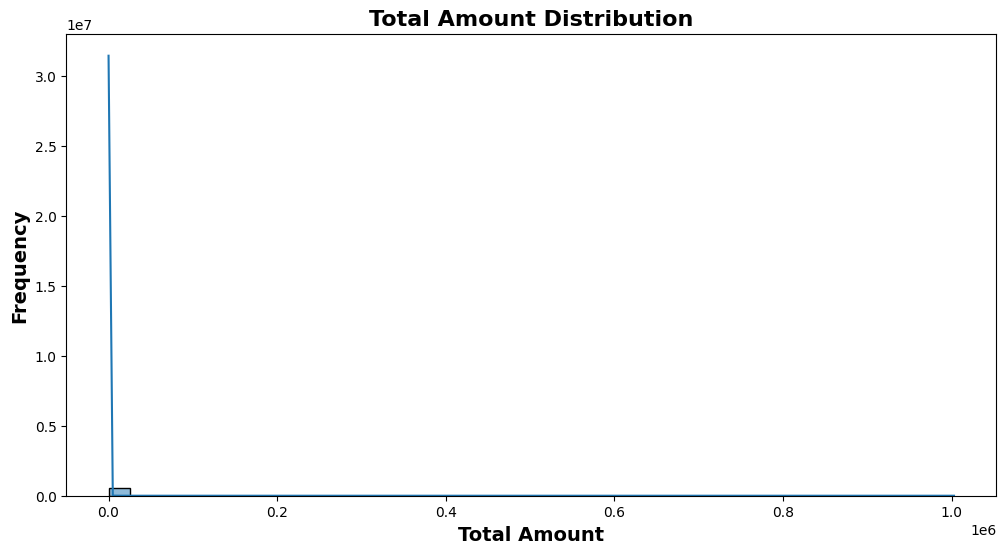

In [341]:
plt.figure(figsize=(12,6))
sns.histplot(df["Total Amount"], bins=40, kde=True)
plt.title("Total Amount Distribution",fontweight="bold",fontsize=16)
plt.xlabel("Total Amount",fontweight="bold",fontsize=14)
plt.ylabel("Frequency",fontweight="bold",fontsize=14)
plt.show()

### 🔍 Insight:


- The distribution is highly right-skewed.
- Most transactions have a very low total amount.
- Only a few transactions have very high values.
- This indicates that small purchases are more common, while large purchases are rare.

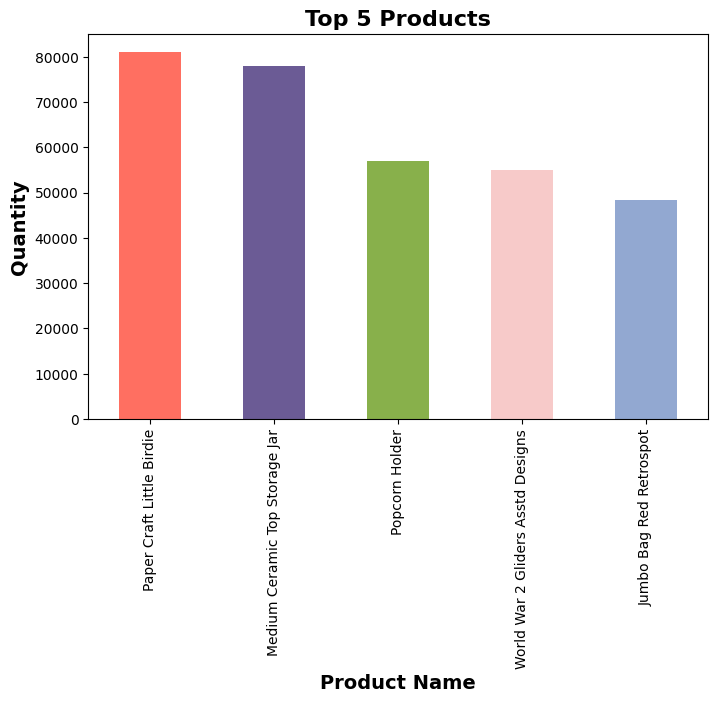

In [342]:
# Top Products
plt.figure(figsize=(8,5))
analysis.top_products().plot(kind="bar",color=['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1'])
plt.title("Top 5 Products",fontweight="bold",fontsize=16)
plt.xlabel("Product Name",fontweight="bold",fontsize=14)
plt.ylabel("Quantity",fontweight="bold",fontsize=14)
plt.xticks(rotation=90)
plt.show()

### 🔍 Insight:
The bar chart shows that a few products have significantly higher sales than others.

👉 This indicates strong demand for these products.

👉 Business Meaning:
The company relies on these top products for a major portion of sales.

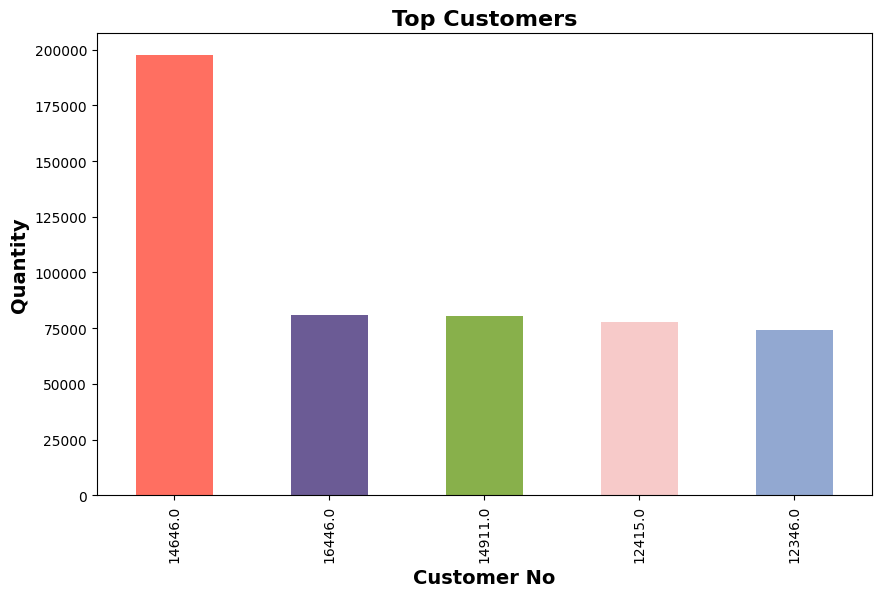

In [343]:
plt.figure(figsize=(10,6))
analysis.top_customers().plot(kind="bar",color=['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1'])
plt.title("Top Customers",fontweight="bold",fontsize=16)
plt.xlabel("Customer No",fontweight="bold",fontsize=14)
plt.ylabel("Quantity", fontweight="bold",fontsize=14)
plt.show()

### 🔍 Insight:
The chart shows that a few customers contribute significantly higher purchases than others.

👉 This indicates that a small group of customers drives a large portion of sales.

👉 Business Meaning:
These customers are key revenue contributors for the business.

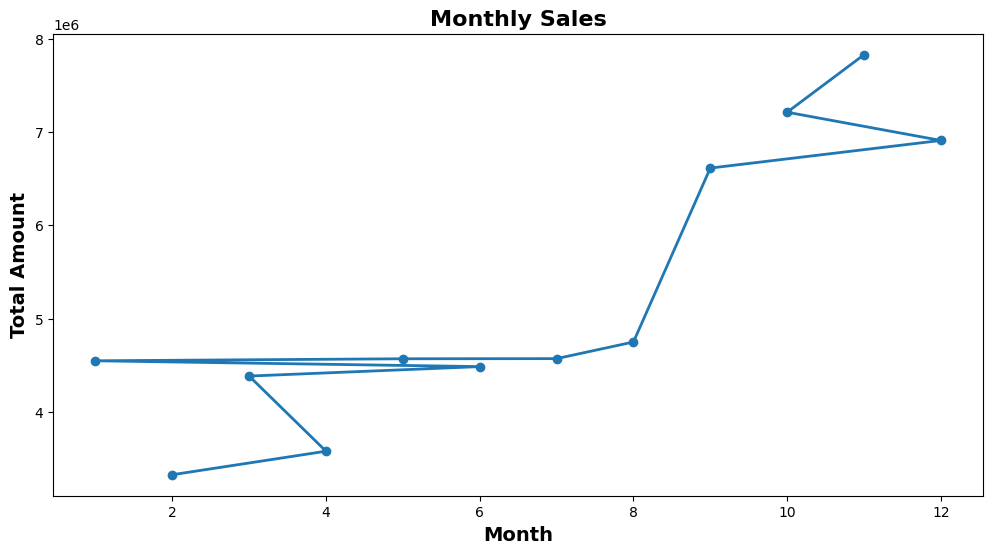

In [344]:
plt.figure(figsize=(12,6))
analysis.monthly_sales().plot(kind="line",marker="o",linewidth=2)
plt.title("Monthly Sales",fontweight="bold",fontsize=16)
plt.xlabel("Month",fontweight="bold",fontsize=14)
plt.ylabel("Total Amount",fontweight="bold",fontsize=14)
plt.show()

### 🔍 Insight:
Clear fluctuation in sales across months

Shows seasonal demand patterns

👉 Business Insight:

Peak months = high demand → increase inventory

Low months → run offers & discounts

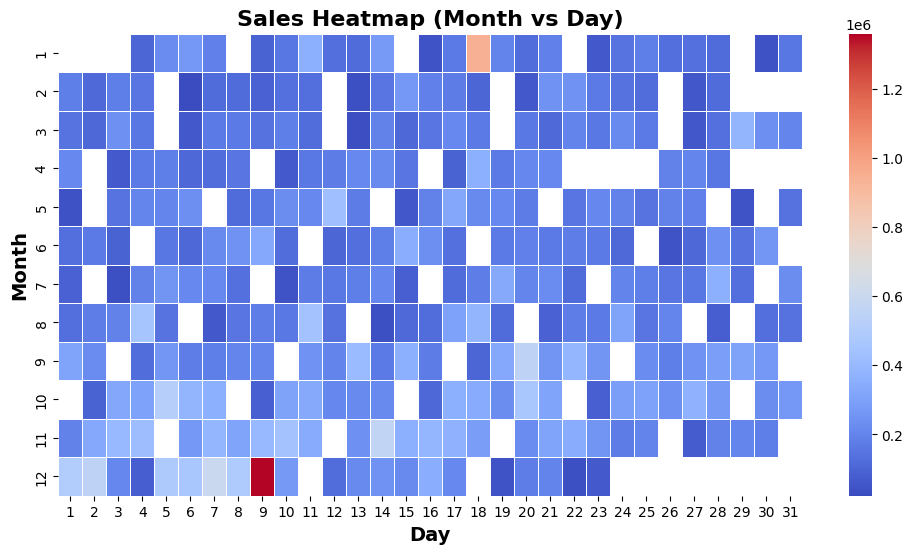

In [355]:
heatmap_data=df.pivot_table(index="Month",columns="Day",values="Total Amount",aggfunc="sum")
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="coolwarm",linewidth=0.5)
plt.title("Sales Heatmap (Month vs Day)",fontweight="bold",fontsize=16)
plt.xlabel("Day",fontweight="bold",fontsize=14)
plt.ylabel("Month",fontweight="bold",fontsize=14)
plt.show()

# 🔍 Insight:

- The heatmap shows variation of sales across days and months

- Darker regions indicate higher sales activity

- Some specific days/months show higher concentration of sales

- This helps identify peak sales periods and patterns

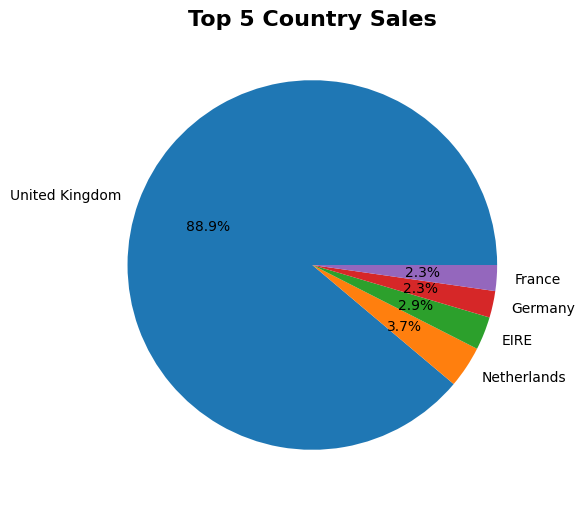

In [345]:
country_sales=df.groupby("Country")["Total Amount"].sum().sort_values(ascending=False).head()
plt.figure(figsize=(10,6))
plt.pie(country_sales,labels=country_sales.index,autopct="%1.1f%%")
plt.title("Top 5 Country Sales",fontweight="bold",fontsize=16)
plt.show()

# 🔍 Insight:

The pie chart shows that a few countries contribute the majority of total sales.

👉 This indicates that revenue is concentrated in limited regions.

👉 Business Meaning:
The company depends heavily on top-performing countries for sales.

## ✅ Conclusion

This project successfully analyzed e-commerce transaction data to uncover key insights related to product performance, customer behavior, and sales trends.

The analysis revealed that sales are highly concentrated among a few top products, customers, and countries, indicating strong dependency on key contributors. Additionally, seasonal patterns were observed in monthly sales, highlighting fluctuations in demand.

By applying data cleaning, feature engineering, and structured analysis using feature abstraction (OOP), the project ensures accurate and efficient insight generation.

👉 Overall, this analysis helps in making data-driven decisions such as improving product strategy, targeting high-value customers, and expanding into new markets.